**Loading** **Dataset**

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Description**:

* **Age**: Age of the patient in years.

* **Sex**: Gender of the patient (Male or Female).

* **ChestPainType**: Type of chest pain experienced by the patient.

* **RestingBP**: Resting blood pressure of the patient in mmHg.

* **Cholesterol**: Serum cholesterol level measured in mg/dl.

* **FastingBS**: Fasting blood sugar status **(1 = high, 0 = normal)**.

* **RestingECG**: Resting electrocardiogram test results.

* **MaxHR**: Maximum heart rate achieved during exercise.

* **ExerciseAngina**: Presence of exercise-induced chest pain.

* **Oldpeak**: ST depression induced by exercise relative to rest.

* **ST_Slope**: Slope of the ST segment during peak exercise.

* **HeartDisease**: Target variable indicating presence or absence of heart disease.

**Dataset** **shape** & **info**()

In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


We can see that our dataset is already clean. There is no missing values in it. So we will perform **EDA** here.

**Exploratory** **Data** **Analysis**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df['Age'].describe()

,Age
count,918.000000
mean,53.510893
std,9.432617
min,28.000000
25%,47.000000
50%,54.000000
75%,60.000000
max,77.000000


* Average age around 54 years

* Most patients are middle aged

* Age varies from young to old adults

In [ ]:
df['RestingBP'].describe()

,RestingBP
count,918.000000
mean,132.396514
std,18.514154
min,0.000000
25%,120.000000
50%,130.000000
75%,140.000000
max,200.000000


* Mean resting BP is around 130 mmHg

* Some patients have very high BP

* High BP increases heart disease risk

In [ ]:
df['Cholesterol'].describe()

,Cholesterol
count,918.000000
mean,198.799564
std,109.384145
min,0.000000
25%,173.250000
50%,223.000000
75%,267.000000
max,603.000000


* Average cholesterol is around 200+

In [ ]:
df['MaxHR'].describe()

,MaxHR
count,918.000000
mean,136.809368
std,25.460334
min,60.000000
25%,120.000000
50%,138.000000
75%,156.000000
max,202.000000


* Average maximum heart rate around 136

* Younger patients have higher MaxHR

* Low MaxHR relates to heart disease

In [ ]:
df['Oldpeak'].describe()

,Oldpeak
count,918.000000
mean,0.887364
std,1.066570
min,-2.600000
25%,0.000000
50%,0.600000
75%,1.500000
max,6.200000


* Mean value around 1

* Higher oldpeak indicates heart stress

In [ ]:
df['HeartDisease'].describe()

,HeartDisease
count,918.000000
mean,0.553377
std,0.497414
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


* Mean shows heart disease proportion

* Around half patients have heart disease

* Binary target variable (0/1)

In [ ]:
df.groupby('Sex')['HeartDisease'].mean()

,HeartDisease
Sex,
F,0.259067
M,0.631724


* Male patients have higher heart disease probability

* Females show lower average risk

In [ ]:
df.groupby('ChestPainType')['HeartDisease'].mean()

,HeartDisease
ChestPainType,
ASY,0.790323
ATA,0.138728
NAP,0.354680
TA,0.434783


* ASY chest pain has highest heart disease risk

* ATA has lowest risk

In [ ]:
df.groupby('ExerciseAngina')['HeartDisease'].mean()

,HeartDisease
ExerciseAngina,
N,0.351005
Y,0.851752


* Exercise angina = Y → high heart disease

* Strong clinical warning sign

In [ ]:
df.groupby('RestingECG')['HeartDisease'].mean()

,HeartDisease
RestingECG,
LVH,0.563830
Normal,0.516304
ST,0.657303


* Some ECG categories show higher disease

* ECG results help diagnosis

In [ ]:
df.groupby('FastingBS')['HeartDisease'].mean()

,HeartDisease
FastingBS,
0,0.480114
1,0.794393


* High fasting sugar patients have more heart disease

* Diabetes is a risk factor

* Binary numerical feature used as category

**EDA**(Plots), **Graphical** **visualizations** for stronger justification and insights.

**Heart Disease Distribution**

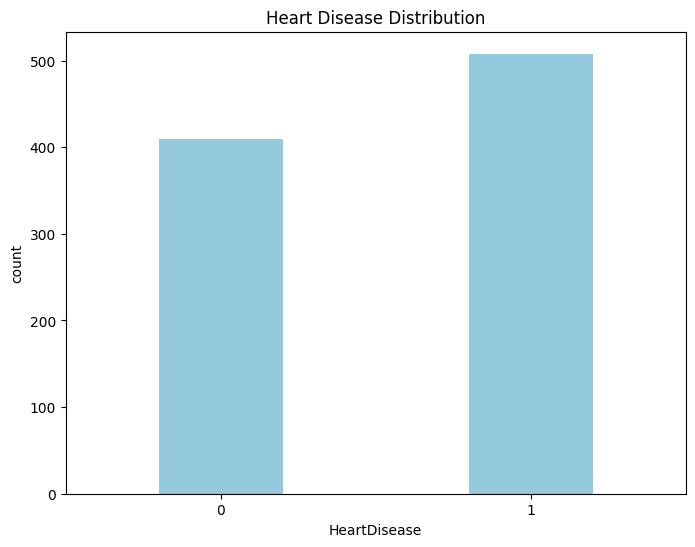

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='HeartDisease',data=df,width=0.4,color='skyblue')
plt.title("Heart Disease Distribution")
plt.show()

* Both classes are present

* Slightly more patients have heart disease

**Age Distribution**

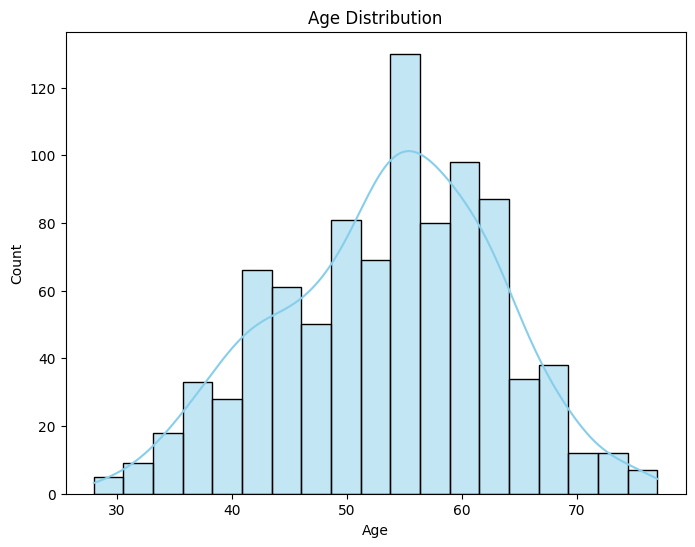

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['Age'],kde=True,color='skyblue')
plt.title("Age Distribution")
plt.show()

* Most patients are between 45–65 years

* Age is slightly right skewed

* Heart disease mostly affects middle-aged people

**Gender Distribution**

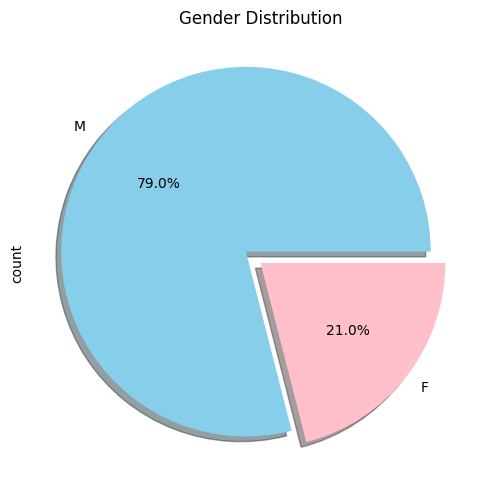

In [ ]:
plt.figure(figsize=(8,6))
explode=(0.1,0)
colors=["skyblue","pink"]
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%',textprops={"fontsize":10},explode=explode,colors=colors,shadow=True)
plt.title("Gender Distribution",fontsize=12)
plt.show()

* Dataset contains more males than females

* Around 75% patients are male

* Gender imbalance is present

**Age vs Cholesterol**

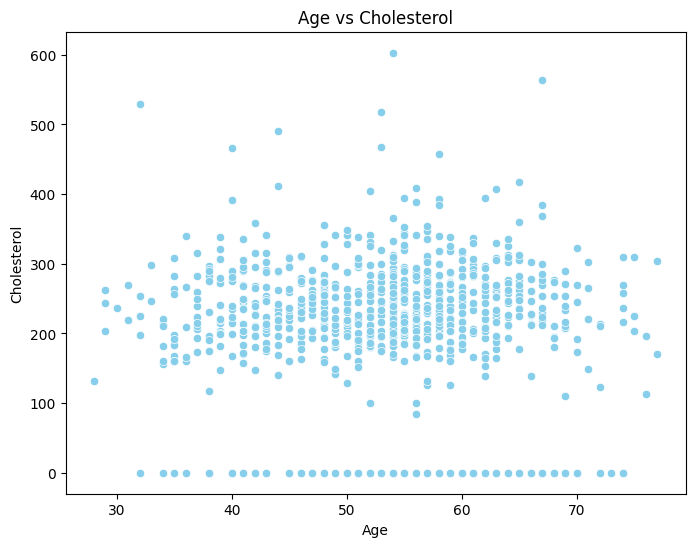

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age',y='Cholesterol',data=df,color='skyblue')
plt.title("Age vs Cholesterol")
plt.show()

* Cholesterol values vary at all ages

**Age vs Max Heart Rate**

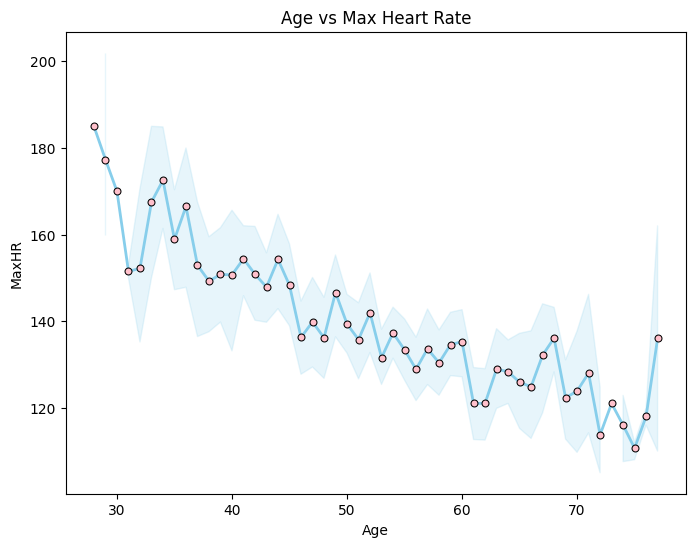

In [ ]:
plt.figure(figsize=(8,6))
sns.lineplot(x='Age',y='MaxHR',data=df,color='skyblue',marker="o",linewidth=2,markerfacecolor="pink",markeredgecolor="black",markersize=5)
plt.title("Age vs Max Heart Rate")
plt.show()

* Max heart rate decreases with age

* Younger patients achieve higher heart rate

* Negative relationship observed

**Heart Disease vs Age**

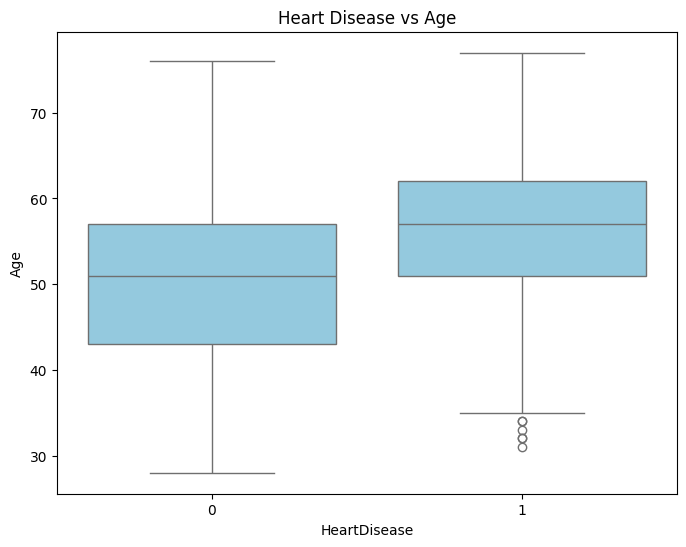

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='HeartDisease',y='Age',data=df,color='skyblue')
plt.title("Heart Disease vs Age")
plt.show()

* Heart disease patients are generally older

* Median age is higher for disease group

**Chest Pain Type vs Heart Disease**

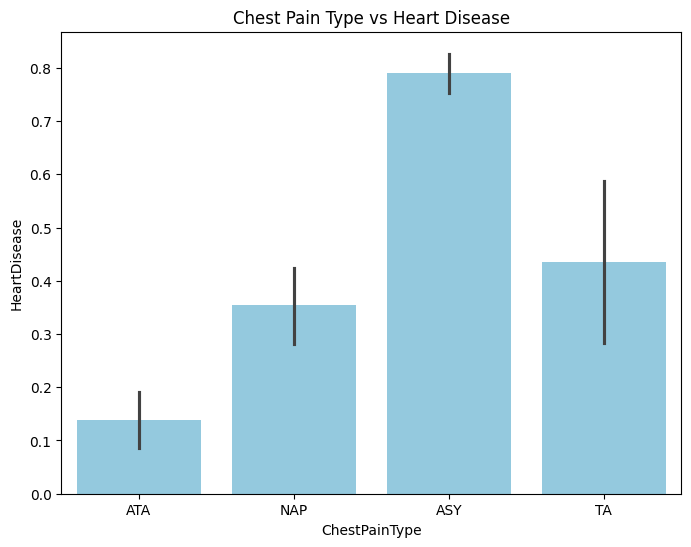

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='ChestPainType',y='HeartDisease',data=df,color='skyblue')
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

* ASY type has highest heart disease risk

* ATA type has lowest risk

**Exercise Angina vs Heart Disease**

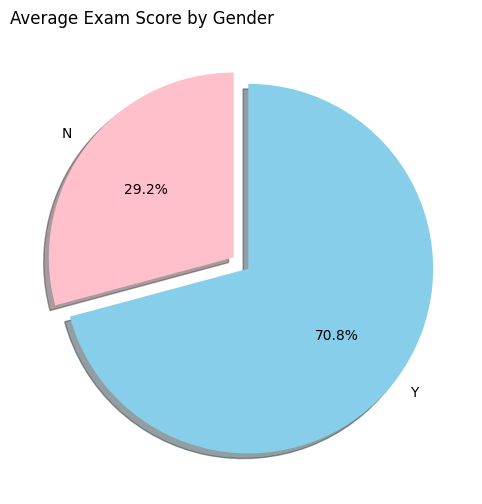

In [ ]:
plt.figure(figsize=(8,6))
x=df.groupby('ExerciseAngina')['HeartDisease'].mean()
explode=[0.05]*len(x)
colors=['pink','skyblue']
plt.pie(x,labels=x.index,shadow=True,autopct='%1.1f%%',textprops={"fontsize":10},explode=explode,colors=colors,startangle=90)
plt.title("Average Exam Score by Gender",loc="left",fontsize=12)
plt.show()

* Patients with Exercise Angina = Y have higher heart disease

* Strong indicator of heart problems

**Correlation Heatmap**

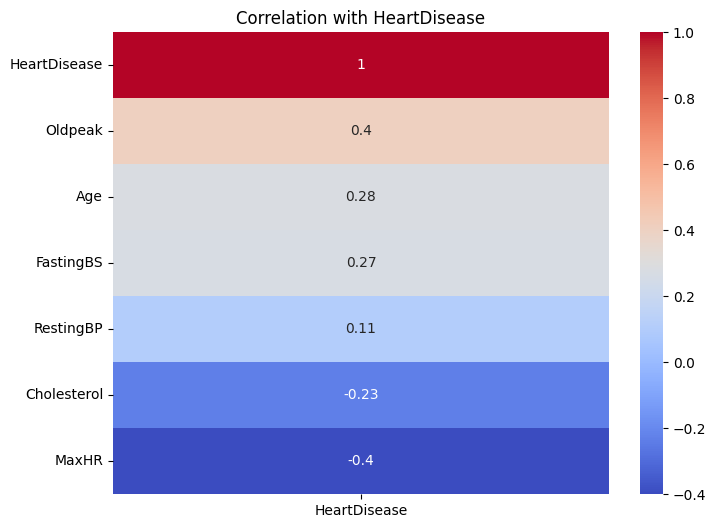

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True)[['HeartDisease']].sort_values(by='HeartDisease', ascending=False),annot=True, cmap='coolwarm')
plt.title("Correlation with HeartDisease")
plt.show()

* This heatmap shows how each numeric feature is related to HeartDisease.

* Values close to 1 mean strong positive correlation (as the feature increases, risk of heart disease increases).

* Values close to -1 mean strong negative correlation (as the feature increases, risk decreases).

Now, we will check **value** **counts** for each column.

In [ ]:
df['Sex'].value_counts()

,count
Sex,
M,725
F,193


* Majority are Male; fewer females,

* Males have higher heart disease risk

In [ ]:
df['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


* Most patients have ASY chest pain; ATA type is least

* Chest pain type affects heart disease.

In [ ]:
df['RestingBP'].value_counts().head().sort_values(ascending=False)

,count
RestingBP,
120,132
130,118
140,107
110,58
150,55


* Most patients have common resting BP values around 110–140

* High BP increases heart risk.


In [ ]:
df['Cholesterol'].value_counts().head().sort_values(ascending=False)

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9


* Cholesterol varies widely; some extreme values present;

* High cholesterol is a risk factor.


In [ ]:
df['FastingBS'].value_counts()

,count
FastingBS,
0,704
1,214


* 0 = normal, 1 = high

* most patients have normal fasting blood sugar

* High sugar increases risk.


In [ ]:
df['RestingECG'].value_counts()

,count
RestingECG,
Normal,552
LVH,188
ST,178


* Most patients have Normal ECG

* Some show ST-T abnormality or LV hypertrophy.


In [ ]:
df['MaxHR'].value_counts().head().sort_values(ascending=False)

,count
MaxHR,
150,43
140,41
120,36
130,33
160,25


* MaxHR ranges widely

* lower values are seen in older or high-risk patients.

In [ ]:
df['ExerciseAngina'].value_counts()

,count
ExerciseAngina,
N,547
Y,371


* Most patients do not have exercise-induced angina

* Presence indicates higher risk.

In [ ]:
df['Oldpeak'].value_counts().head().sort_values(ascending=False)

,count
Oldpeak,
0.0,368
1.0,86
2.0,76
1.5,53
3.0,28


* Higher Oldpeak indicates more heart stress.


In [ ]:
df['ST_Slope'].value_counts()

,count
ST_Slope,
Flat,460
Up,395
Down,63


* Most patients have Up slope

* Flat or Down slopes indicate higher risk.


In [ ]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


* Slightly more patients have heart disease

**Encoding**

Here, we can see that **Age** is already a numerical, no encoding is required.

The next column is **Sex**, on which we apply **Label** **Encoding** since it is a **binary** **categorical** **variable**.

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder1=LabelEncoder()
df["Sex"]=encoder1.fit_transform(df["Sex"])
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0


After completing the encoding of the **Sex** column, we move to the **Chest Pain Type** column. **OneHotEncoding**  is applied since it is a **nominal** categorical feature with no inherent order.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder2=OneHotEncoder()
x=encoder2.fit_transform(df[["ChestPainType"]]).toarray()
x

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

The encoding for this column has been completed and it is now merged back into the original dataset.

In [ ]:
encoder2_df=pd.DataFrame(x,columns=encoder2.get_feature_names_out())
df=pd.concat([df,encoder2_df],axis=1)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0,0.0,1.0,0.0,0.0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0.0,0.0,1.0,0.0
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0,0.0,1.0,0.0,0.0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1.0,0.0,0.0,0.0
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0,0.0,0.0,1.0,0.0


Now, The **Resting ECG** feature will be encoded using **One** **Hot** **Encoding** becuase it's best for Nominal Categorical Features.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder3=OneHotEncoder()
y=encoder3.fit_transform(df[["RestingECG"]]).toarray()
y

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       ...,
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [ ]:
encoder3_df=pd.DataFrame(y,columns=encoder3.get_feature_names_out())
df=pd.concat([df,encoder3_df],axis=1)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Next column is **Exercise** **Angina**, we can use **Label** **Encoding** here because of binary categorical values.

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder4=LabelEncoder()
df["ExerciseAngina"]=encoder4.fit_transform(df["ExerciseAngina"])
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Now, The last column is **ST** **Slope**, we can use **OneHotEncoding** here because it doesn't follow any natural order.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder5=OneHotEncoder()
z=encoder5.fit_transform(df[["ST_Slope"]]).toarray()
z

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [ ]:
encoder5_df=pd.DataFrame(z,columns=encoder5.get_feature_names_out())
df=pd.concat([df,encoder5_df],axis=1)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,...,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,ATA,140,289,0,Normal,172,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,ATA,130,283,0,ST,98,0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,NAP,150,195,0,Normal,122,0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


Will drop the categorical columns from the dataset.

In [ ]:
df=df.drop(["ChestPainType","RestingECG","ST_Slope"],axis=1)

From here, we will separate **Independent** and **Dependent** variables

In [ ]:
x=df.drop(["HeartDisease"],axis=1)
y=df["HeartDisease"]

**Scaling**:

So, that all features are brought to the same scale.

In [ ]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()

In [ ]:
x=scale.fit_transform(x)

Splitting Dataset into training and testing data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

**Choosing** **the** **best** **model**

**1**. **Logistic** **Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
classifier=LogisticRegression()

In [ ]:
classifier.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=classifier.predict(x_test)

In [ ]:
y_test

,HeartDisease
306,1
711,0
298,1
466,1
253,0
...,...
909,1
293,1
761,1
2,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(accuracy_score(y_test,y_pred))

0.8260869565217391


**2**. **Decission** **Tree** **Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(x_train,y_train)
y_pred=dtc.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.7608695652173914


**3**. **Naive** **Bayes** **Classifier**

In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier=GaussianNB()
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8315217391304348


**4**. **Random** **Forest** **Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)
y_pred=rfc.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.8478260869565217


**Here, we can see that the accuracy score of all the models is almost the same**

Now we will take input from the user and generate predictions.

In [ ]:
age=int(input("Enter your age: "))
sex=(input("Enter your sex (M/F): "))
chestpaintype=(input("Enter your chest pain type (ASY/ATA/NAP/TA): "))
restingbp=int(input("Enter your resting blood pressure: "))
cholesterol=int(input("Enter your cholesterol level: "))
fastingbs=int(input("Enter your fasting blood sugar (0/1): "))
restingecg=(input("Enter your ECG results (Normal/ST/LVH): "))
maxhr=int(input("Enter your maximum heart rate: "))
exerciseangina=(input("Enter your exercise-induced angina (Yes/No): "))
oldpeak=float(input("Enter your oldpeak value: "))
stslope=(input("Enter your ST slope (Up/Flat/Down): "))


if sex=="Male":
  sex=1
else:
  sex=0

if chestpaintype=="ASY":
  chestpaintype_ASY=1
  chestpaintype_ATA=0
  chestpaintype_NAP=0
  chestpaintype_TA=0
elif chestpaintype=="ATA":
  chestpaintype_ASY=0
  chestpaintype_ATA=1
  chestpaintype_NAP=0
  chestpaintype_TA=0
elif chestpaintype=="NAP":
  chestpaintype_ASY=0
  chestpaintype_ATA=0
  chestpaintype_NAP=1
  chestpaintype_TA=0
else:
  chestpaintype_ASY=1
  chestpaintype_ATA=0
  chestpaintype_NAP=0
  chestpaintype_TA=0

if restingecg=="Normal":
  restingecg_Normal=1
  restingecg_ST=0
  restingecg_LVH=0
elif restingecg=="ST":
  restingecg_Normal=0
  restingecg_ST=1
  restingecg_LVH=0
else:
  restingecg_Normal=0
  restingecg_ST=0
  restingecg_LVH=1

if exerciseangina=="Yes":
  exerciseangina=1
else:
  exerciseangina=0

if stslope=="Up":
  stslope_Up=1
  stslope_Flat=0
  stslope_Down=0
elif stslope=="Flat":
  stslope_Up=0
  stslope_Flat=1
  stslope_Down=0
else:
  stslope_Up=0
  stslope_Flat=0
  stslope_Down=1


Enter your age: 21
Enter your sex (M/F): f
Enter your chest pain type (ASY/ATA/NAP/TA): ta
Enter your resting blood pressure: 122
Enter your cholesterol level: 110
Enter your fasting blood sugar (0/1): 1
Enter your ECG results (Normal/ST/LVH): lvh
Enter your maximum heart rate: 99
Enter your exercise-induced angina (Yes/No): yes
Enter your oldpeak value: 3
Enter your ST slope (Up/Flat/Down): up


In [ ]:
import numpy as np
x=np.array([[age,sex,restingbp,cholesterol,fastingbs,maxhr,exerciseangina,oldpeak,chestpaintype_ASY,chestpaintype_ATA,chestpaintype_NAP,chestpaintype_TA,restingecg_LVH,restingecg_Normal,restingecg_ST,stslope_Down,stslope_Flat,stslope_Up]])


In [ ]:
x=scale.transform(x)
pred=rfc.predict(x)
pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1])